In [2]:
# Importação de bibliotecas relevantes
import re
import time
import json
import os
import requests
import pandas as pd

# Listando os 5 primeiros Sistemas Autônomos

In [3]:
COUNTRIES = ["IR", "IL", "SY", "IQ", "LB"]
CACHE_FILE = "asn_cache.json"

def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE) as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f)

def get_json(url, params, retries=4, timeout=40):
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except (requests.exceptions.RequestException,) as e:
            wait = 2 ** attempt  # backoff: 1s, 2s, 4s, 8s
            print(f"  tentativa {attempt+1}/{retries} falhou ({e}); esperando {wait}s")
            time.sleep(wait)
    return None  # desistiu depois de N tentativas

def get_routed_asns(country):
    data = get_json("https://stat.ripe.net/data/country-asns/data.json",
                     {"resource": country, "lod": 1})
    routed_str = data["data"]["countries"][0]["routed"]
    return [int(x) for x in re.findall(r"AsnSingle\((\d+)\)", routed_str)]

def get_as_info(asn):
    name, n_prefixes = "unknown", 0
    d1 = get_json("https://stat.ripe.net/data/as-overview/data.json", {"resource": f"AS{asn}"})
    if d1:
        name = d1["data"].get("holder", "unknown")
    d2 = get_json("https://stat.ripe.net/data/announced-prefixes/data.json", {"resource": f"AS{asn}"})
    if d2:
        n_prefixes = len(d2["data"].get("prefixes", []))
    return name, n_prefixes

cache = load_cache()  # {"IR-12880": {"name":..., "n_prefixes":...}, ...}

for country in COUNTRIES:
    asns = get_routed_asns(country)
    print(f"{country}: {len(asns)} ASNs roteados")
    for i, asn in enumerate(asns):
        key = f"{country}-{asn}"
        if key in cache:
            continue  # já processado numa rodada anterior
        name, n_prefixes = get_as_info(asn)
        cache[key] = {"country": country, "asn": asn, "name": name, "n_prefixes": n_prefixes}
        if i % 20 == 0:
            save_cache(cache)  # salva a cada 20 pra não perder progresso
            print(f"  {i+1}/{len(asns)} processados")
        time.sleep(0.3)
    save_cache(cache)

df = pd.DataFrame(cache.values())
df = df.sort_values(["country", "n_prefixes"], ascending=[True, False])
top5 = df.groupby("country").head(5)
top5.to_csv("5asns_por_pais.csv", index=False)
print(top5)

IR: 575 ASNs roteados
  1/575 processados
  21/575 processados
  41/575 processados
  61/575 processados
  81/575 processados
  tentativa 1/4 falhou (HTTPSConnectionPool(host='stat.ripe.net', port=443): Read timed out. (read timeout=40)); esperando 1s
  101/575 processados
  121/575 processados
  141/575 processados
  161/575 processados
  181/575 processados
  201/575 processados
  221/575 processados
  241/575 processados
  261/575 processados
  281/575 processados
  301/575 processados
  321/575 processados
  341/575 processados
  361/575 processados
  381/575 processados
  401/575 processados
  421/575 processados
  441/575 processados
  461/575 processados
  481/575 processados
  501/575 processados
  tentativa 1/4 falhou (HTTPSConnectionPool(host='stat.ripe.net', port=443): Read timed out. (read timeout=40)); esperando 1s
  521/575 processados
  541/575 processados
  561/575 processados
IL: 328 ASNs roteados
  1/328 processados
  21/328 processados
  41/328 processados
  61/328 p

# Coletando séries temporais de BGP

In [5]:
df_asns = pd.read_csv("5asns_por_pais.csv")

# remove Radware e Cato Networks (empresas de segurança/cloud, não provedores residenciais)
df_asns = df_asns[~df_asns["asn"].isin([198949, 13150])]

# adiciona o AS12880 (TIC, gateway internacional do Irã) manualmente, visto que é alvo de constantes bloqueios
# adiciona manualmente Cellcom e Pelephone (operadora fixa e móvel de Israel) no lugar da Radware e da Cato Networks
extra = pd.DataFrame([
    {"country": "IR", "asn": 12880, "name": "TIC (gateway internacional)", "n_prefixes": None},
    {"country": "IL", "asn": 1680, "name": "Cellcom Fixed Line Communication L.P", "n_prefixes": None},
    {"country": "IL", "asn": 16116, "name": "Pelephone Communications Ltd.", "n_prefixes": None},
])
df_asns = pd.concat([df_asns, extra], ignore_index=True)

all_updates = []
all_activity = []

def get_bgp_updates(asn, start, end):
    r = requests.get(
        "https://stat.ripe.net/data/bgp-updates/data.json",
        params={"resource": f"AS{asn}", "starttime": start, "endtime": end},
        timeout=40,
    )
    r.raise_for_status()
    updates = r.json()["data"]["updates"]
    rows = []
    for u in updates:
        rows.append({
            "asn": asn,
            "timestamp": u["timestamp"],
            "type": u["type"],
            "prefix": u.get("attrs", {}).get("target_prefix"),
        })
    return rows

def get_update_activity(asn, start, end):
    r = requests.get(
        "https://stat.ripe.net/data/bgp-update-activity/data.json",
        params={"resource": f"AS{asn}", "starttime": start, "endtime": end},
        timeout=40,
    )
    r.raise_for_status()
    return r.json()["data"].get("updates", [])

# Janelas temporais de eventos em análise
EVENTS = [
    {"country": "IR", "label": "guerra_ira_2026",        "start": "2026-06-10T00:00", "end": "2026-06-25T00:00"},
    {"country": "LB", "label": "conflito_hezbollah_2024", "start": "2024-09-15T00:00", "end": "2024-11-30T00:00"},
    {"country": "SY", "label": "protestos_primavera_arabe_2011", "start": "2011-03-10T00:00", "end": "2011-04-10T00:00"},
    {"country": "SY", "label": "apagao_nacional_2012",   "start": "2012-11-27T00:00", "end": "2012-12-05T00:00"},
    {"country": "SY", "label": "queda_assad_2024",       "start": "2024-11-25T00:00", "end": "2024-12-15T00:00"},
    {"country": "IL", "label": "guerra_ira_2026",        "start": "2026-06-10T00:00", "end": "2026-06-25T00:00"},
    {"country": "IQ", "label": "guerra_ira_2026",        "start": "2026-06-10T00:00", "end": "2026-06-25T00:00"},
    {"country": "SY","label": "apagao_parcial_junho_2011","start": "2011-06-01T00:00","end": "2011-06-06T00:00"}
]

for event in EVENTS:
    country = event["country"]
    start, end = event["start"], event["end"]
    label = event["label"]

    asns_do_pais = df_asns[df_asns["country"] == country]

    for _, row in asns_do_pais.iterrows():
        asn = int(row["asn"])
        print(f"[{label}] buscando AS{asn} ({country}) entre {start} e {end}")
        try:
            updates = get_bgp_updates(asn, start, end)
            for u in updates:
                u["event"] = label
            all_updates.extend(updates)
        except Exception as e:
            print(f"  erro em bgp-updates AS{asn}: {e}")
        try:
            activity = get_update_activity(asn, start, end)
            for a in activity:
                a["asn"] = asn
                a["country"] = country
                a["event"] = label
            all_activity.extend(activity)
        except Exception as e:
            print(f"  erro em bgp-update-activity AS{asn}: {e}")
        time.sleep(0.5)

df_updates = pd.DataFrame(all_updates)
df_activity = pd.DataFrame(all_activity)

df_updates.to_csv("bgp_updates_raw.csv", index=False)
df_activity.to_csv("bgp_update_activity.csv", index=False)

df_updates["date"] = pd.to_datetime(df_updates["timestamp"]).dt.date  # timestamp ja vem em ISO8601, nao em epoch Unix
df_updates = df_updates.merge(df_asns[["asn", "country"]], on="asn", how="left")

withdrawals_by_day = (
    df_updates[df_updates["type"] == "W"]
    .groupby(["event", "country", "date"])
    .size()
    .reset_index(name="n_withdrawals")
)
withdrawals_by_day.to_csv("withdrawals_por_dia.csv", index=False)
print(withdrawals_by_day)

[guerra_ira_2026] buscando AS58224 (IR) entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em bgp-updates AS58224: HTTPSConnectionPool(host='stat.ripe.net', port=443): Read timed out. (read timeout=40)
[guerra_ira_2026] buscando AS197207 (IR) entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em bgp-updates AS197207: HTTPSConnectionPool(host='stat.ripe.net', port=443): Read timed out. (read timeout=40)
[guerra_ira_2026] buscando AS42337 (IR) entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em bgp-updates AS42337: HTTPSConnectionPool(host='stat.ripe.net', port=443): Read timed out. (read timeout=40)
[guerra_ira_2026] buscando AS44244 (IR) entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em bgp-updates AS44244: HTTPSConnectionPool(host='stat.ripe.net', port=443): Read timed out. (read timeout=40)
[guerra_ira_2026] buscando AS43754 (IR) entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em bgp-updates AS43754: 502 Server Error: Bad Gateway for url: https://stat.ripe.net/data/bgp-updates/data.js

In [8]:
def get_ioda_signal(entity_code, start_unix, end_unix, datasource="bgp"):
    r = requests.get(
        f"https://api.ioda.inetintel.cc.gatech.edu/v2/signals/raw/country/{entity_code}",
        params={"from": start_unix, "until": end_unix, "datasource": datasource},
        timeout=40,
    )
    r.raise_for_status()
    return r.json()

# Calculando metricas quantitativas

In [ ]:
def get_country_resource_stats(country, start, end, resolution="1h"):
    r = requests.get(
        "https://stat.ripe.net/data/country-resource-stats/data.json",
        params={"resource": country, "starttime": start, "endtime": end, "resolution": resolution},
        timeout=40,
    )
    r.raise_for_status()
    stats = r.json()["data"]["stats"]
    rows = []
    for s in stats:
        rows.append({
            "country": country,
            "timestamp": s["timeline"]["starttime"],
            "v4_prefixes_visiveis": s.get("v4_prefixes_ris"),
            "v6_prefixes_visiveis": s.get("v6_prefixes_ris"),
            "asns_visiveis": s.get("asns_ris"),
        })
    return rows

all_visibility = []

for event in EVENTS:
    country, label, start, end = event["country"], event["label"], event["start"], event["end"]
    print(f"[{label}] prefixos visiveis de {country} entre {start} e {end}")
    try:
        rows = get_country_resource_stats(country, start, end, resolution="1h")
        for r in rows:
            r["event"] = label
        all_visibility.extend(rows)
    except Exception as e:
        print(f"  erro em country-resource-stats {country}: {e}")
    time.sleep(0.5)

df_visibility = pd.DataFrame(all_visibility)
if df_visibility.empty:
    print("ATENCAO: nenhum dado de country-resource-stats foi coletado. Verifique os erros impressos acima.")
else:
    df_visibility["date"] = pd.to_datetime(df_visibility["timestamp"])
    df_visibility.to_csv("prefixos_visiveis_por_evento.csv", index=False)
    print(df_visibility)


[guerra_ira_2026] prefixos visiveis de IR entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em country-resource-stats IR: list indices must be integers or slices, not str
[conflito_hezbollah_2024] prefixos visiveis de LB entre 2024-09-15T00:00 e 2024-11-30T00:00
  erro em country-resource-stats LB: list indices must be integers or slices, not str
[protestos_primavera_arabe_2011] prefixos visiveis de SY entre 2011-03-10T00:00 e 2011-04-10T00:00
  erro em country-resource-stats SY: list indices must be integers or slices, not str
[apagao_nacional_2012] prefixos visiveis de SY entre 2012-11-27T00:00 e 2012-12-05T00:00
  erro em country-resource-stats SY: list indices must be integers or slices, not str
[queda_assad_2024] prefixos visiveis de SY entre 2024-11-25T00:00 e 2024-12-15T00:00
  erro em country-resource-stats SY: list indices must be integers or slices, not str
[guerra_ira_2026] prefixos visiveis de IL entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em country-resource-stats IL: 

In [10]:
from datetime import datetime, timezone

def iso_to_unix(iso_str):
    return int(datetime.fromisoformat(iso_str).replace(tzinfo=timezone.utc).timestamp())

all_ioda = []

for event in EVENTS:
    country, label, start, end = event["country"], event["label"], event["start"], event["end"]
    start_unix, end_unix = iso_to_unix(start), iso_to_unix(end)
    print(f"[{label}] sinal IODA de {country} entre {start} e {end}")
    try:
        data = get_ioda_signal(country, start_unix, end_unix, datasource="ping-slash24")
        for series in data.get("data", []):
            for point_ts, value in zip(
                range(series["from"], series["until"], series["step"]),
                series["values"]
            ):
                all_ioda.append({
                    "country": country,
                    "event": label,
                    "timestamp": point_ts,
                    "sinal_ioda": value,
                })
    except Exception as e:
        print(f"  erro em IODA {country}: {e}")
    time.sleep(0.5)

df_ioda = pd.DataFrame(all_ioda)
if not df_ioda.empty:
    df_ioda["date"] = pd.to_datetime(df_ioda["timestamp"], unit="s")  # aqui SIM e epoch Unix (retorno do IODA)
    df_ioda.to_csv("sinal_ioda_por_evento.csv", index=False)
else:
    df_ioda["date"] = pd.Series(dtype="datetime64[ns]")

# junta com a serie de prefixos visiveis pra comparar as duas linhas no Grafico 2
ioda_diario = df_ioda.groupby(["event", "country", df_ioda["date"].dt.date])["sinal_ioda"].mean().reset_index() if not df_ioda.empty else pd.DataFrame(columns=["event","country","date","sinal_ioda"])
if not df_visibility.empty:
    visibility_diario = df_visibility.groupby(["event", "country", df_visibility["date"].dt.date])[["v4_prefixes_visiveis", "asns_visiveis"]].mean().reset_index()
else:
    visibility_diario = pd.DataFrame(columns=["event", "country", "date", "v4_prefixes_visiveis", "asns_visiveis"])

df_comparativo = pd.merge(ioda_diario, visibility_diario, on=["event", "country", "date"], how="outer")
df_comparativo.to_csv("comparativo_trafego_bgp.csv", index=False)
print(df_comparativo)


[guerra_ira_2026] sinal IODA de IR entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em IODA IR: list indices must be integers or slices, not str
[conflito_hezbollah_2024] sinal IODA de LB entre 2024-09-15T00:00 e 2024-11-30T00:00
  erro em IODA LB: list indices must be integers or slices, not str
[protestos_primavera_arabe_2011] sinal IODA de SY entre 2011-03-10T00:00 e 2011-04-10T00:00
  erro em IODA SY: list indices must be integers or slices, not str
[apagao_nacional_2012] sinal IODA de SY entre 2012-11-27T00:00 e 2012-12-05T00:00
  erro em IODA SY: list indices must be integers or slices, not str
[queda_assad_2024] sinal IODA de SY entre 2024-11-25T00:00 e 2024-12-15T00:00
  erro em IODA SY: list indices must be integers or slices, not str
[guerra_ira_2026] sinal IODA de IL entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em IODA IL: list indices must be integers or slices, not str
[guerra_ira_2026] sinal IODA de IQ entre 2026-06-10T00:00 e 2026-06-25T00:00
  erro em IODA IQ: list 

# Graficos

C:\Users\danie\AppData\Local\Temp\ipykernel_33124\3065099491.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))


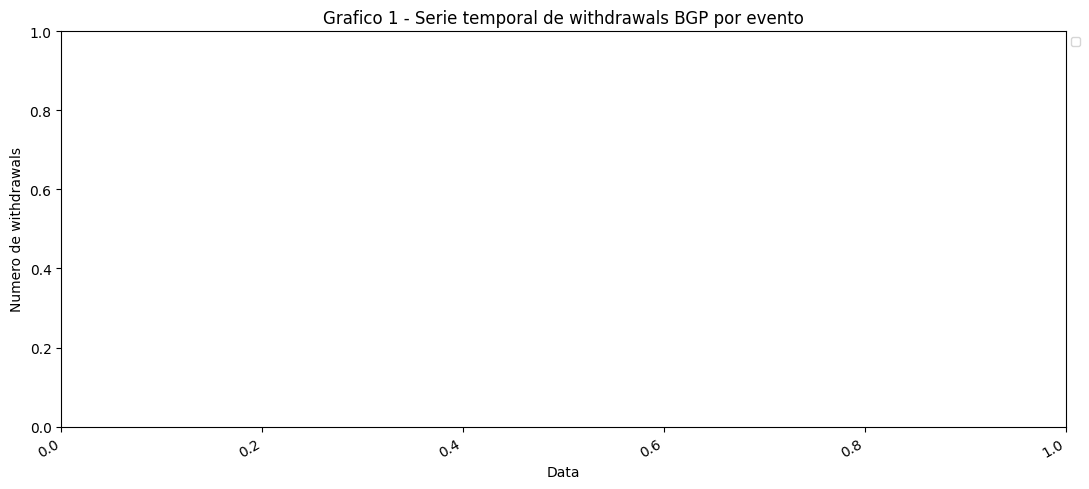

In [11]:
import matplotlib.pyplot as plt

wd = pd.read_csv("withdrawals_por_dia.csv", parse_dates=["date"])

fig, ax = plt.subplots(figsize=(11, 5))
for (event, country), grupo in wd.groupby(["event", "country"]):
    ax.plot(grupo["date"], grupo["n_withdrawals"], marker="o", label=f"{country} - {event}")

ax.set_title("Grafico 1 - Serie temporal de withdrawals BGP por evento")
ax.set_xlabel("Data")
ax.set_ylabel("Numero de withdrawals")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("grafico1_withdrawals.png", dpi=150)
plt.show()


In [12]:
comp = pd.read_csv("comparativo_trafego_bgp.csv", parse_dates=["date"])

eventos_unicos = comp["event"].dropna().unique()

for evento in eventos_unicos:
    sub = comp[comp["event"] == evento].sort_values("date")
    if sub["v4_prefixes_visiveis"].isna().all() and sub["sinal_ioda"].isna().all():
        continue
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    ax2 = ax1.twinx()

    ax1.plot(sub["date"], sub["v4_prefixes_visiveis"], color="tab:blue", marker="o", label="Prefixos BGP visiveis")
    ax2.plot(sub["date"], sub["sinal_ioda"], color="tab:red", marker="s", label="Sinal IODA (trafego real)")

    ax1.set_ylabel("Prefixos BGP visiveis (v4)", color="tab:blue")
    ax2.set_ylabel("Sinal IODA (ping-slash24)", color="tab:red")
    ax1.set_xlabel("Data")
    ax1.set_title(f"Grafico 2 - Anomalia BGP vs. Trafego real ({evento})")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(f"grafico2_{evento}.png", dpi=150)
    plt.show()
